In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Étape 1 — Chargement des données

In [2]:
# Chargement du dataset
df = pd.read_csv("titanic.csv")

# Aperçu des données
df.head()

,Unnamed: 0,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
# dimensions du dataset
df.shape

(891, 16)

In [4]:
# Description des types de variables 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   891 non-null    int64  
 1   survived     891 non-null    int64  
 2   pclass       891 non-null    int64  
 3   sex          891 non-null    object 
 4   age          714 non-null    float64
 5   sibsp        891 non-null    int64  
 6   parch        891 non-null    int64  
 7   fare         891 non-null    float64
 8   embarked     889 non-null    object 
 9   class        891 non-null    object 
 10  who          891 non-null    object 
 11  adult_male   891 non-null    bool   
 12  deck         203 non-null    object 
 13  embark_town  889 non-null    object 
 14  alive        891 non-null    object 
 15  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(5), object(7)
memory usage: 99.3+ KB


In [5]:
df.describe()

,Unnamed: 0,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,445.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,222.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,445.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,667.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,890.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
# Étape 2 : Exploration et visualisation

In [6]:
# Calculer la proportion de survivants et non survivants
df['survived'].value_counts(normalize=True)

survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

In [7]:
# Afficher le nombre brut de survivants et non survivants
df['survived'].value_counts()

survived
0    549
1    342
Name: count, dtype: int64

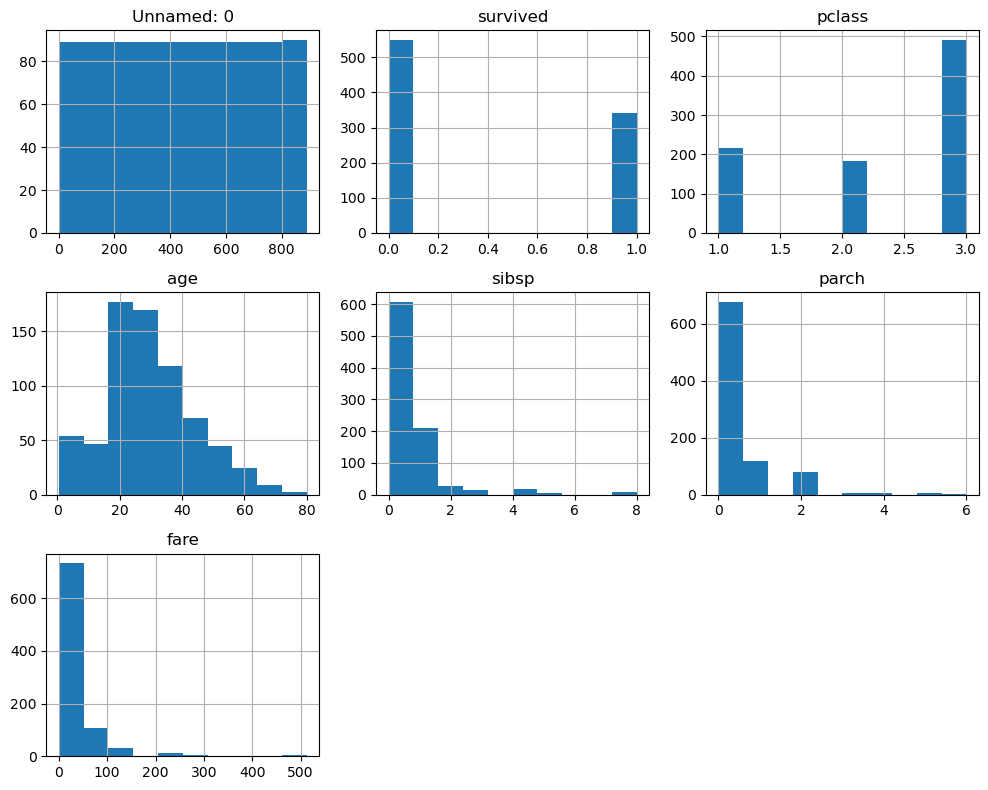

In [8]:
# Afficher les histogrammes pour toutes les variables numériques
df.hist(figsize=(10,8))  # Définir la taille de la figure

plt.tight_layout()       # Ajuster automatiquement les espacements
plt.show()               # Afficher les graphiques

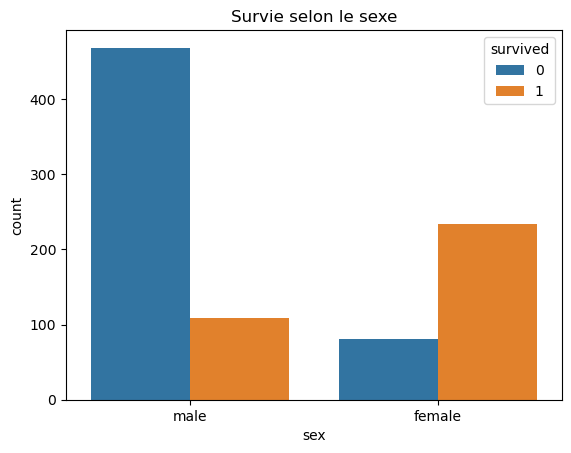

In [10]:
# Graphique du nombre de survivants selon le sexe
sns.countplot(x='sex', hue='survived', data=df)

plt.title("Survie selon le sexe")  # Ajouter un titre
plt.show()  # Afficher le graphique

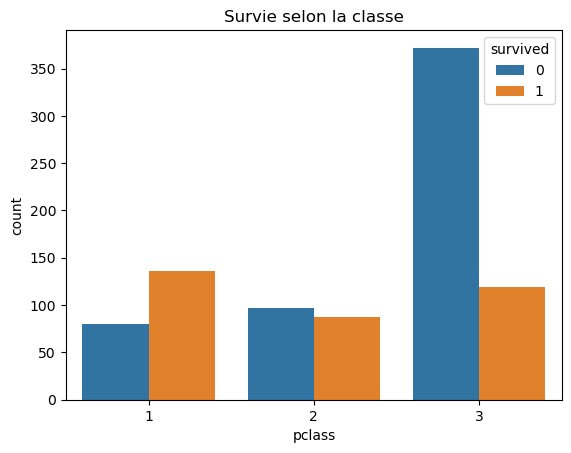

In [11]:
# Graphique du nombre de survivants selon la classe sociale
sns.countplot(x='pclass', hue='survived', data=df)

plt.title("Survie selon la classe")  # Ajouter un titre
plt.show()  # Afficher le graphique

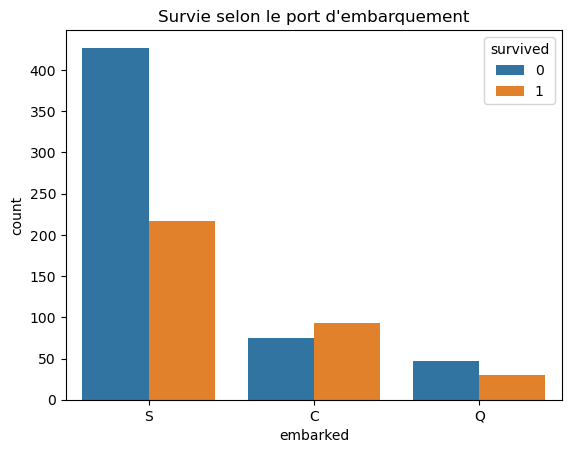

In [12]:
# Graphique du nombre de survivants selon le port d'embarquement
sns.countplot(x='embarked', hue='survived', data=df)

plt.title("Survie selon le port d'embarquement")  # Ajouter un titre
plt.show()  # Afficher le graphique

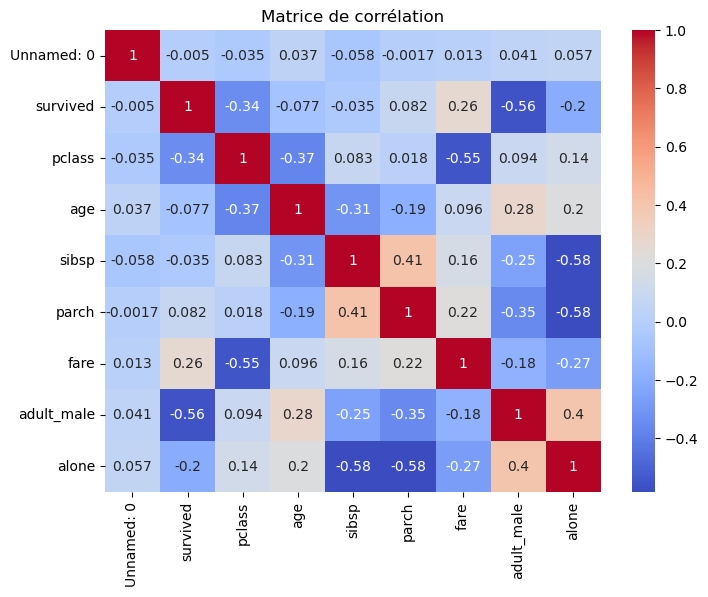

In [13]:
# Créer une figure de taille personnalisée
plt.figure(figsize=(8,6))

# Calculer et afficher la matrice de corrélation pour les variables numériques
sns.heatmap(df.corr(numeric_only=True), 
            annot=True,       # Afficher les valeurs numériques
            cmap='coolwarm')  # Choisir la palette de couleurs

plt.title("Matrice de corrélation")
plt.show()  # Afficher la heatmap

In [ ]:
# Étape 3 — Traitement des valeurs manquantes

In [14]:
# Compter le nombre de valeurs manquantes par colonne
df.isnull().sum()

Unnamed: 0       0
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [15]:
# Calculer le pourcentage de valeurs manquantes
(df.isnull().sum() / len(df)) * 100

Unnamed: 0      0.000000
survived        0.000000
pclass          0.000000
sex             0.000000
age            19.865320
sibsp           0.000000
parch           0.000000
fare            0.000000
embarked        0.224467
class           0.000000
who             0.000000
adult_male      0.000000
deck           77.216611
embark_town     0.224467
alive           0.000000
alone           0.000000
dtype: float64

In [16]:
# Faire une copie du dataset original pour sécurité
df_original = df.copy() 

In [17]:
# Suppression des variables redondantes ou inutiles
df = df.drop(columns=['Unnamed: 0', 'alive'])

In [18]:
from sklearn.impute import SimpleImputer

# Créer l'imputeur avec la stratégie médiane
median_imputer = SimpleImputer(strategy='median')

# Imputer uniquement la colonne age
df['age_median'] = median_imputer.fit_transform(df[['age']])

# Supprimer l'ancienne colonne age si nécessaire
df = df.drop(columns=['age'])

In [19]:
from sklearn.impute import KNNImputer

# Sélectionner uniquement les variables numériques
num_cols = df.select_dtypes(include=['int64','float64']).columns

# Créer l'imputeur KNN
knn_imputer = KNNImputer(n_neighbors=5)

# Appliquer l'imputation
df_knn[num_cols] = knn_imputer.fit_transform(df_knn[num_cols])

In [20]:
# Imputation des variables catégorielles avec la valeur la plus fréquente
cat_imputer = SimpleImputer(strategy='most_frequent')

df[['embarked','embark_town']] = cat_imputer.fit_transform(
    df[['embarked','embark_town']]
)

In [24]:
df.head()

,survived,pclass,sex,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alone,age_median
0,0,3,male,1,0,7.2500,S,Third,man,True,NaN,Southampton,False,22.0
1,1,1,female,1,0,71.2833,C,First,woman,False,C,Cherbourg,False,38.0
2,1,3,female,0,0,7.9250,S,Third,woman,False,NaN,Southampton,True,26.0
3,1,1,female,1,0,53.1000,S,First,woman,False,C,Southampton,False,35.0
4,0,3,male,0,0,8.0500,S,Third,man,True,NaN,Southampton,True,35.0


In [ ]:
# Étape 4 — Détection des outliers

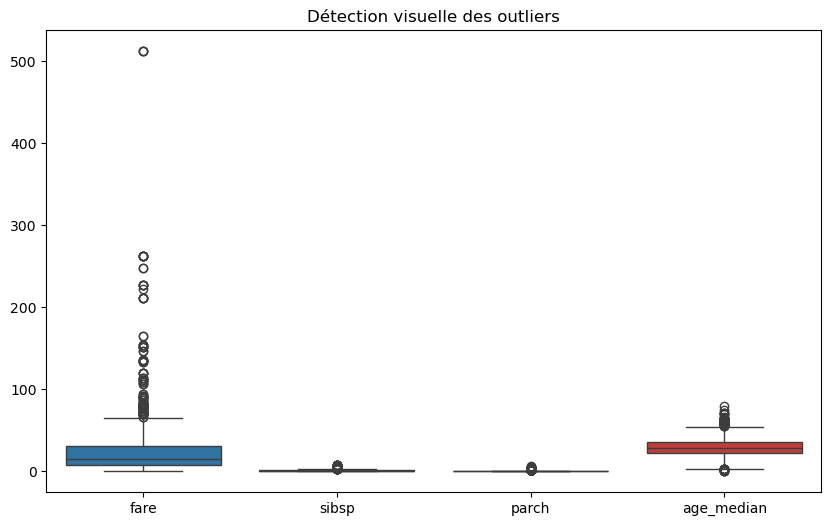

In [25]:
# Boxplot pour détecter visuellement les outliers
plt.figure(figsize=(10,6))

# Variables numériques à analyser
sns.boxplot(data=df[['fare','sibsp','parch','age_median']])

plt.title("Détection visuelle des outliers")
plt.show()

In [26]:
# Fonction de détection des outliers avec IQR
def detect_outliers_iqr(data, column):
    
    # Calcul du premier quartile (25%)
    Q1 = data[column].quantile(0.25)
    
    # Calcul du troisième quartile (75%)
    Q3 = data[column].quantile(0.75)
    
    # Calcul de l'IQR
    IQR = Q3 - Q1
    
    # Bornes inférieure et supérieure
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    return data[(data[column] < lower_bound) | (data[column] > upper_bound)]

# Détection des outliers pour fare
outliers_fare = detect_outliers_iqr(df, 'fare')

# Afficher le nombre d'outliers
len(outliers_fare)

116

In [27]:
# Capping des valeurs extrêmes de fare
Q1 = df['fare'].quantile(0.25)
Q3 = df['fare'].quantile(0.75)
IQR = Q3 - Q1

# Bornes
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Application du capping
df['fare'] = df['fare'].clip(lower_bound, upper_bound)

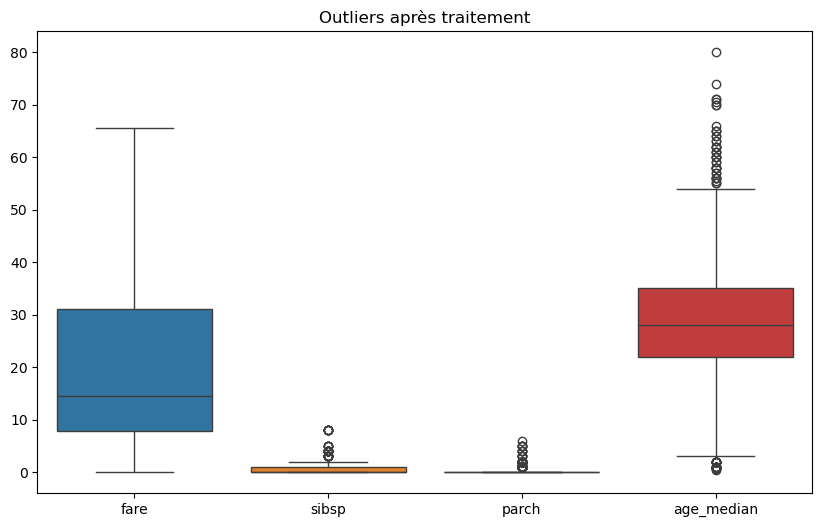

In [28]:
# Revisualiser les boxplots après traitement
plt.figure(figsize=(10,6))

sns.boxplot(data=df[['fare','sibsp','parch','age_median']])

plt.title("Outliers après traitement")
plt.show()

In [ ]:
# Étape 5 — Prétraitement et encodage

In [30]:
# Définir la variable cible
y = df['survived']

# Supprimer la variable cible du dataset features
X = df.drop(columns=['survived'])

In [31]:
# Variables numériques
num_features = X.select_dtypes(include=['int64','float64']).columns

# Variables catégorielles
cat_features = X.select_dtypes(include=['object','bool']).columns

In [32]:
from sklearn.preprocessing import OneHotEncoder

# Encoder les variables catégorielles
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

In [33]:
from sklearn.preprocessing import StandardScaler

# Standardisation des variables numériques
numerical_transformer = StandardScaler()

In [34]:
from sklearn.compose import ColumnTransformer

# Combiner les transformations
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, num_features),
        ('cat', categorical_transformer, cat_features)
    ])

In [ ]:
# Étape 6 — Séparation features et target

In [35]:
from sklearn.model_selection import train_test_split

# Séparer dataset en train et test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [36]:
# Appliquer transformation sur les données d'entraînement
X_train_transformed = preprocessor.fit_transform(X_train)

# Appliquer transformation sur les données test
X_test_transformed = preprocessor.transform(X_test)

In [ ]:
# Étape 7 — Modélisation

In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

In [38]:
# Pipeline pour la régression logistique
logistic_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000))
])

# Pipeline pour Random Forest
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(random_state=42))
])

In [39]:
# Entraîner la régression logistique
logistic_pipeline.fit(X_train, y_train)

# Entraîner Random Forest
rf_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [40]:
# Définir la grille d’hyperparamètres
param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [5, 10, None],
    'model__min_samples_split': [2, 5]
}

# GridSearchCV
grid_search = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=5,
    scoring='accuracy'
)

# Entraîner la recherche d’hyperparamètres
grid_search.fit(X_train, y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__max_depth': [5, 10, ...], 'model__min_samples_split': [2, 5], 'model__n_estimators': [100, 200]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [41]:
# Afficher les meilleurs paramètres
grid_search.best_params_

# Meilleur score obtenu
grid_search.best_score_

np.float64(0.8272136314389835)

In [42]:
# Utiliser le meilleur modèle trouvé
best_model = grid_search.best_estimator_

In [ ]:
# Étape 8 — Evaluation

In [43]:
from sklearn.metrics import accuracy_score, precision_score
from sklearn.metrics import recall_score, f1_score
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

In [44]:
# Prédictions des modèles
y_pred_log = logistic_pipeline.predict(X_test)
y_pred_rf = best_model.predict(X_test)

# Probabilités pour la courbe ROC
y_prob_log = logistic_pipeline.predict_proba(X_test)[:,1]
y_prob_rf = best_model.predict_proba(X_test)[:,1]

In [45]:
def evaluate_model(y_true, y_pred, y_prob, model_name):

    print(f"\n{model_name}")

    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision :", precision_score(y_true, y_pred))
    print("Recall :", recall_score(y_true, y_pred))
    print("F1 Score :", f1_score(y_true, y_pred))
    print("AUC :", roc_auc_score(y_true, y_prob))

# Évaluer les deux modèles
evaluate_model(y_test, y_pred_log, y_prob_log, "Logistic Regression")
evaluate_model(y_test, y_pred_rf, y_prob_rf, "Random Forest")


Logistic Regression
Accuracy : 0.7932960893854749
Precision : 0.7534246575342466
Recall : 0.7432432432432432
F1 Score : 0.7482993197278912
AUC : 0.8736164736164735

Random Forest
Accuracy : 0.8100558659217877
Precision : 0.8225806451612904
Recall : 0.6891891891891891
F1 Score : 0.75
AUC : 0.8885456885456886


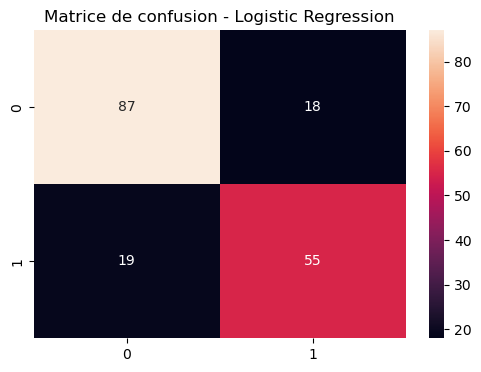

In [46]:
# Matrice de confusion Logistic Regression
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred_log),
            annot=True,
            fmt='d')

plt.title("Matrice de confusion - Logistic Regression")
plt.show()

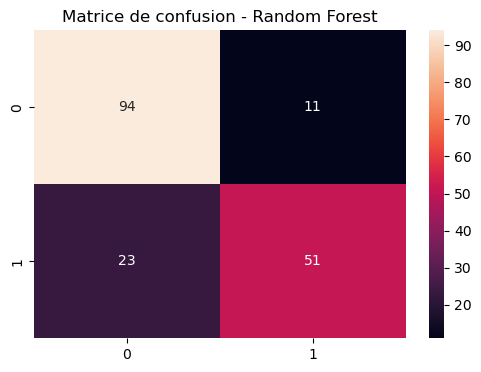

In [47]:
# Matrice de confusion Random Forest
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred_rf),
            annot=True,
            fmt='d')

plt.title("Matrice de confusion - Random Forest")
plt.show()

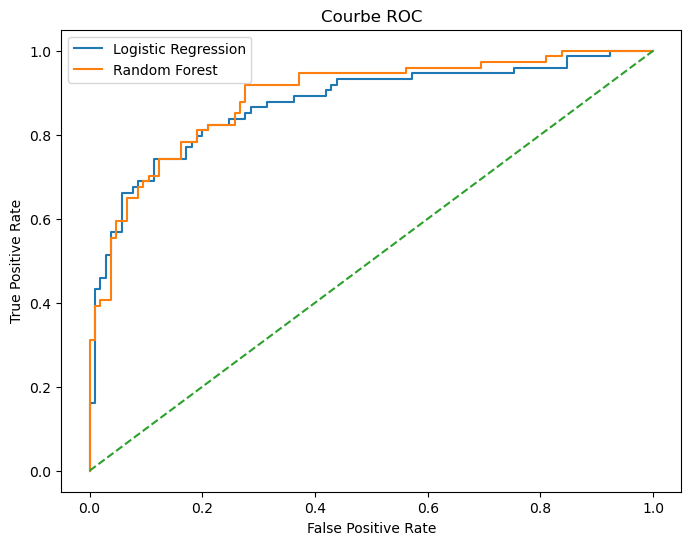

In [48]:
# ROC Logistic Regression
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)

# ROC Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(8,6))

plt.plot(fpr_log, tpr_log, label="Logistic Regression")
plt.plot(fpr_rf, tpr_rf, label="Random Forest")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Courbe ROC")
plt.legend()

plt.show()